# NB20 — Cross-Model Replication: Qwen1.5-7B Geometry

**Goal:** Test whether the two-subspace geometric finding generalises beyond LLaMA-3.1-8B-Instruct.

**Three key claims to replicate on Qwen1.5-7B:**
1. **Task-identity constellations** — do activations cluster by task at mid-layers? (peak silhouette)
2. **OR direction misalignment** — is the over-refusal DIM direction misaligned with the  
   harmful-refusal DIM direction (cosine ≈ 0.45 in LLaMA)?
3. **OR subspace is higher-dimensional** — does over-refusal require more PCA components  
   for 80% variance than harmful-refusal (11 vs 8 in LLaMA)?

**No GPU / model loading needed** — this notebook works entirely from pre-computed  
Qwen1.5-7B embeddings (extracted in NB4) and the associated evaluation CSV.

**Comparison approach:**  
Side-by-side figures plot LLaMA (reference) and Qwen (replication) for each analysis.  
If the structure is qualitatively consistent, the finding is model-general.

**Note on labels:**  
The Qwen evaluation CSV contains refusal labels from Qwen1.5-7B-Chat's own generations  
(same prompts, Qwen as judge target). If label counts differ substantially from LLaMA,  
we document this and interpret accordingly.

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import os
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif',
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.grid': True,
    'grid.alpha': 0.3, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 2.2,
})

PAL = {
    'llama':  '#2C3E50',   # dark blue-grey
    'qwen':   '#E74C3C',   # red
    'ref':    '#7F8C8D',   # grey reference lines
    'chance': '#BDC3C7',
}

print('✓ Libraries loaded. GPU not required.')

✓ Libraries loaded. GPU not required.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ── Qwen embeddings ────────────────────────────────────────────────────────────
os.makedirs('./embeddings_qwen', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval_qwen_1_5/." ./embeddings_qwen/.

# ── LLaMA embeddings (for side-by-side comparison) ────────────────────────────
os.makedirs('./embeddings_llama', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings_llama/.

# ── Arditi artefacts (LLaMA reference direction) ──────────────────────────────
os.makedirs('./arditi_artefacts', exist_ok=True)
!cp -a /content/drive/MyDrive/Colab\ Notebooks/SteeringFail/arditi_artefacts/* arditi_artefacts/

Mounted at /content/drive
cp: cannot open '/content/drive/MyDrive/embeddings/overalign_eval/llama/./overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.gsheet' for reading: Operation not supported


## Load Embeddings

In [4]:
def load_embeddings(emb_dir):
    """
    Load embeddings from a directory containing a CSV pointer and torch file.
    Returns: texts, embeddings_np, text_type_labels, intended_task_labels,
             response_labels, refusal_labels, layer_names, layer_nums
    """
    csv_files = sorted(f for f in os.listdir(emb_dir) if f.endswith('.csv'))
    if not csv_files:
        raise FileNotFoundError(f'No CSV found in {emb_dir}')
    csv_path = os.path.join(emb_dir, csv_files[-1])
    csv_df   = pd.read_csv(csv_path)

    # Construct the full path to the torch file by joining emb_dir with the path from the CSV
    torch_file_relative_path = csv_df['torch_path'].iloc[0]
    torch_file_path = os.path.join(emb_dir, os.path.basename(torch_file_relative_path))

    torch_data = torch.load(torch_file_path)
    emb_raw    = torch_data['embeddings']

    # Convert to numpy
    embeddings_np = {}
    for k, v in emb_raw.items():
        if isinstance(v, torch.Tensor):
            embeddings_np[k] = v.float().numpy().astype(np.float32)
        else:
            embeddings_np[k] = np.array([e.float().numpy().astype(np.float32) for e in v])

    texts                = torch_data['texts']
    text_type_labels     = np.array(torch_data['text_type_labels'])
    intended_task_labels = np.array(torch_data['intended_task_labels'])
    response_labels      = csv_df['llm_evaluation'].values
    refusal_labels       = csv_df['refusal_class'].values

    # Layer ordering
    layer_names = sorted(
        [k for k in embeddings_np if 'input_norm' in k],
        key=lambda x: int(x.split('layer_')[1].split('_')[0])
    )
    layer_nums  = [int(ln.split('layer_')[1].split('_')[0]) for ln in layer_names]

    return (texts, embeddings_np, text_type_labels, intended_task_labels,
            response_labels, refusal_labels, layer_names, layer_nums)


print('Loading Qwen embeddings...')
(
    texts_q, emb_q, tt_labels_q, it_labels_q,
    resp_labels_q, ref_labels_q, layer_names_q, layer_nums_q
) = load_embeddings('./embeddings_qwen')

print('Loading LLaMA embeddings...')
(
    texts_l, emb_l, tt_labels_l, it_labels_l,
    resp_labels_l, ref_labels_l, layer_names_l, layer_nums_l
) = load_embeddings('./embeddings_llama')

print()
print(f'Qwen:  {len(texts_q)} samples | {len(layer_names_q)} layers | dim={list(emb_q.values())[0].shape[1]}')
print(f'LLaMA: {len(texts_l)} samples | {len(layer_names_l)} layers | dim={list(emb_l.values())[0].shape[1]}')


Loading Qwen embeddings...
Loading LLaMA embeddings...

Qwen:  270 samples | 31 layers | dim=4096
LLaMA: 270 samples | 31 layers | dim=4096


In [5]:
def make_masks(text_type_labels, intended_task_labels, response_labels, refusal_labels):
    """
    Compute behavioural masks identical to NB13a/NB14/NB16 for any model's labels.
    """
    REFUSING  = (refusal_labels == 'direct_refusal') | (refusal_labels == 'indirect_refusal')
    ANSWERED  = refusal_labels == 'direct_answer'
    HARMFUL   = text_type_labels == 'harmful_instruction'
    BENIGN_T  = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
    BENIGN    = np.isin(intended_task_labels, BENIGN_T)

    OR_MASK   = BENIGN & REFUSING   # over-refusal
    TGT_MASK  = ((response_labels == 'cautious') | (response_labels == 'not_harmful')) & ANSWERED
    RH_MASK   = HARMFUL & REFUSING  # refused-harmful
    HA_MASK   = ~HARMFUL & ANSWERED  # harmless-answered (strict)

    return OR_MASK, TGT_MASK, RH_MASK, HA_MASK


OR_q, TGT_q, RH_q, HA_q = make_masks(tt_labels_q, it_labels_q, resp_labels_q, ref_labels_q)
OR_l, TGT_l, RH_l, HA_l = make_masks(tt_labels_l, it_labels_l, resp_labels_l, ref_labels_l)

for model, OR, TGT, RH, HA in [('Qwen', OR_q, TGT_q, RH_q, HA_q),
                                 ('LLaMA', OR_l, TGT_l, RH_l, HA_l)]:
    print(f'{model}:')
    print(f'  Over-refusal: {OR.sum()}  |  Target: {TGT.sum()}  |  '
          f'Refused-harmful: {RH.sum()}  |  Harmless-answered: {HA.sum()}')

Qwen:
  Over-refusal: 22  |  Target: 221  |  Refused-harmful: 1  |  Harmless-answered: 216
LLaMA:
  Over-refusal: 48  |  Target: 169  |  Refused-harmful: 25  |  Harmless-answered: 191


## Analysis 1: Task-Identity Constellations (Silhouette)

Replicate NB13a: does Qwen show the same task-clustering at mid-layers?

In [6]:
def compute_silhouettes(embeddings_np, layer_names, intended_task_labels,
                        sample_frac=1.0, random_state=42):
    """
    Compute inter-task silhouette score at each layer.
    Returns (layer_nums, silhouette_scores).
    """
    le  = LabelEncoder()
    y   = le.fit_transform(intended_task_labels)
    lnums = [int(ln.split('layer_')[1].split('_')[0]) for ln in layer_names]

    scores = []
    for lname in layer_names:
        X = embeddings_np[lname]
        if X.shape[1] > 512:
            # PCA-reduce for speed (silhouette is scale-invariant)
            pca = PCA(n_components=min(256, X.shape[0]-1), random_state=random_state)
            X   = pca.fit_transform(X)
        s = silhouette_score(X, y, metric='euclidean', sample_size=None)
        scores.append(s)

    return np.array(lnums), np.array(scores)


print('Computing silhouettes — Qwen...')
lnums_q, sil_q = compute_silhouettes(emb_q, layer_names_q, it_labels_q)
print(f'  Qwen  peak: {sil_q.max():.3f} at L{lnums_q[sil_q.argmax()]}')

print('Computing silhouettes — LLaMA...')
lnums_l, sil_l = compute_silhouettes(emb_l, layer_names_l, it_labels_l)
print(f'  LLaMA peak: {sil_l.max():.3f} at L{lnums_l[sil_l.argmax()]}')

QWEN_PEAK_LAYER  = int(lnums_q[sil_q.argmax()])
LLAMA_PEAK_LAYER = int(lnums_l[sil_l.argmax()])
print(f'\nQwen constellation peak: L{QWEN_PEAK_LAYER}')
print(f'LLaMA constellation peak: L{LLAMA_PEAK_LAYER}  (expected: L12)')

Computing silhouettes — Qwen...
  Qwen  peak: 0.458 at L5
Computing silhouettes — LLaMA...
  LLaMA peak: 0.357 at L12

Qwen constellation peak: L5
LLaMA constellation peak: L12  (expected: L12)


## Analysis 2: OR Direction vs Harmful-Refusal DIM Direction

Replicate NB14 claim: cosine(OR direction, global DIM direction) ≈ 0.45 in LLaMA.  
Does Qwen show a similar misalignment?

In [7]:
def compute_dim_direction(emb, mask_a, mask_b):
    """DIM direction: mean(A) - mean(B), normalised."""
    mu_a = emb[mask_a].mean(axis=0)
    mu_b = emb[mask_b].mean(axis=0)
    d    = mu_a - mu_b
    norm = np.linalg.norm(d)
    return d / (norm + 1e-8) if norm > 1e-8 else d


def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


def compute_cosine_profile(embeddings_np, layer_names,
                           OR_MASK, TGT_MASK, RH_MASK, HA_MASK):
    """
    At each layer compute:
      - OR direction: DIM(OR, TGT)
      - Global harmful-refusal direction: DIM(RH, HA)
      - Cosine between them
    Also compute per-task OR directions and their pairwise cosines.
    """
    cosines = []
    lnums   = [int(ln.split('layer_')[1].split('_')[0]) for ln in layer_names]

    for lname in layer_names:
        emb = embeddings_np[lname]
        if OR_MASK.sum() < 2 or TGT_MASK.sum() < 2 or RH_MASK.sum() < 2 or HA_MASK.sum() < 2:
            cosines.append(np.nan)
            continue
        or_dir  = compute_dim_direction(emb, OR_MASK, TGT_MASK)
        rh_dir  = compute_dim_direction(emb, RH_MASK, HA_MASK)
        cosines.append(cosine(or_dir, rh_dir))

    return np.array(lnums), np.array(cosines)


# Check we have enough samples
for name, OR, TGT, RH, HA in [('Qwen', OR_q, TGT_q, RH_q, HA_q),
                                ('LLaMA', OR_l, TGT_l, RH_l, HA_l)]:
    print(f'{name}: OR={OR.sum()}, TGT={TGT.sum()}, RH={RH.sum()}, HA={HA.sum()}')

print('\nComputing cosine profiles...')
lnums_q_c, cos_q = compute_cosine_profile(emb_q, layer_names_q, OR_q, TGT_q, RH_q, HA_q)
lnums_l_c, cos_l = compute_cosine_profile(emb_l, layer_names_l, OR_l, TGT_l, RH_l, HA_l)

print(f'Qwen  mid-layer cosine (peak layer L{QWEN_PEAK_LAYER}): {cos_q[lnums_q_c == QWEN_PEAK_LAYER][0]:.3f}')
print(f'LLaMA mid-layer cosine (peak layer L{LLAMA_PEAK_LAYER}): {cos_l[lnums_l_c == LLAMA_PEAK_LAYER][0]:.3f}  (expected ≈ 0.45)')

Qwen: OR=22, TGT=221, RH=1, HA=216
LLaMA: OR=48, TGT=169, RH=25, HA=191

Computing cosine profiles...
Qwen  mid-layer cosine (peak layer L5): nan
LLaMA mid-layer cosine (peak layer L12): 0.910  (expected ≈ 0.45)


In [8]:
# ── Per-task OR direction pairwise cosines at peak layer ──────────────────────
BENIGN_TASKS = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
REFUSING_q   = (ref_labels_q == 'direct_refusal') | (ref_labels_q == 'indirect_refusal')
ANSWERED_q   = ref_labels_q == 'direct_answer'
BENIGN_q     = np.isin(it_labels_q, BENIGN_TASKS)


def per_task_or_directions(embeddings_np, layer_name, intended_task_labels,
                            OR_MASK, TGT_MASK, min_n=5):
    """
    Compute per-task over-refusal direction at a single layer.
    Returns dict: task -> direction vector (or None if insufficient samples).
    """
    emb    = embeddings_np[layer_name]
    tasks  = np.unique(intended_task_labels[OR_MASK])  # only tasks with OR samples
    result = {}
    for task in tasks:
        task_mask    = intended_task_labels == task
        or_task_mask = OR_MASK  & task_mask
        tgt_task_mask= TGT_MASK & task_mask
        if or_task_mask.sum() < min_n or tgt_task_mask.sum() < min_n:
            result[task] = None
            continue
        result[task] = compute_dim_direction(emb, or_task_mask, tgt_task_mask)
    return result


for model, emb, layer_names, OR, TGT, it_labels in [
    ('Qwen',  emb_q, layer_names_q, OR_q, TGT_q, it_labels_q),
    ('LLaMA', emb_l, layer_names_l, OR_l, TGT_l, it_labels_l),
]:
    peak_layer = QWEN_PEAK_LAYER if model == 'Qwen' else LLAMA_PEAK_LAYER
    lname = f'layer_{peak_layer}_input_norm'
    if lname not in emb:
        print(f'{model}: layer {lname} not found — skipping per-task analysis')
        continue
    task_dirs = per_task_or_directions(emb, lname, it_labels, OR, TGT, min_n=5)
    valid = {k: v for k, v in task_dirs.items() if v is not None}

    print(f'\n{model} — per-task OR directions at L{peak_layer}:')
    if len(valid) < 2:
        print(f'  Only {len(valid)} task(s) with ≥5 OR samples: {list(valid.keys())}')
        print('  Cannot compute pairwise cosines — not enough tasks.')
    else:
        task_list = list(valid.keys())
        for i, t1 in enumerate(task_list):
            for t2 in task_list[i+1:]:
                c = cosine(valid[t1], valid[t2])
                print(f'  cos({t1}, {t2}) = {c:.3f}')
    print(f'  (LLaMA reference: sentiment vs translate = 0.564)')


Qwen — per-task OR directions at L5:
  Only 1 task(s) with ≥5 OR samples: [np.str_('cryptanalysis')]
  Cannot compute pairwise cosines — not enough tasks.
  (LLaMA reference: sentiment vs translate = 0.564)

LLaMA — per-task OR directions at L12:
  cos(sentiment_analysis, translate) = 0.563
  (LLaMA reference: sentiment vs translate = 0.564)


## Analysis 3: Subspace Dimensionality

In [9]:
def subspace_dimensionality(embeddings_np, layer_names, OR_MASK, RH_MASK,
                             var_threshold=0.80):
    """
    At each layer, compute:
      - PC1 variance explained for OR and RH subspaces
      - n_components for var_threshold cumulative variance
    Returns DataFrame.
    """
    rows = []
    for lname in layer_names:
        lnum = int(lname.split('layer_')[1].split('_')[0])
        emb  = embeddings_np[lname]

        row = {'layer': lnum}
        for label, mask in [('or', OR_MASK), ('rh', RH_MASK)]:
            sub = emb[mask]
            if sub.shape[0] < 5:
                row[f'{label}_pc1_var'] = np.nan
                row[f'{label}_n80']     = np.nan
                continue
            n_comp = min(sub.shape[0] - 1, sub.shape[1])
            pca    = PCA(n_components=n_comp, random_state=42)
            pca.fit(sub)
            cumvar = np.cumsum(pca.explained_variance_ratio_)
            n80    = int(np.searchsorted(cumvar, var_threshold)) + 1
            row[f'{label}_pc1_var'] = float(pca.explained_variance_ratio_[0])
            row[f'{label}_n80']     = n80
        rows.append(row)

    return pd.DataFrame(rows)


print('Computing dimensionality — Qwen...')
dim_q = subspace_dimensionality(emb_q, layer_names_q, OR_q, RH_q)

print('Computing dimensionality — LLaMA...')
dim_l = subspace_dimensionality(emb_l, layer_names_l, OR_l, RH_l)

# Report at peak layers
for model, dim, peak in [('Qwen', dim_q, QWEN_PEAK_LAYER),
                          ('LLaMA', dim_l, LLAMA_PEAK_LAYER)]:
    row = dim[dim['layer'] == peak].iloc[0]
    print(f'\n{model} at L{peak}:')
    print(f'  OR:  PC1={row.or_pc1_var:.1%}  n80={row.or_n80:.0f}')
    print(f'  RH:  PC1={row.rh_pc1_var:.1%}  n80={row.rh_n80:.0f}')

Computing dimensionality — Qwen...
Computing dimensionality — LLaMA...

Qwen at L5:
  OR:  PC1=64.1%  n80=2
  RH:  PC1=nan%  n80=nan

LLaMA at L12:
  OR:  PC1=24.5%  n80=11
  RH:  PC1=30.3%  n80=8


## Comparison Figures

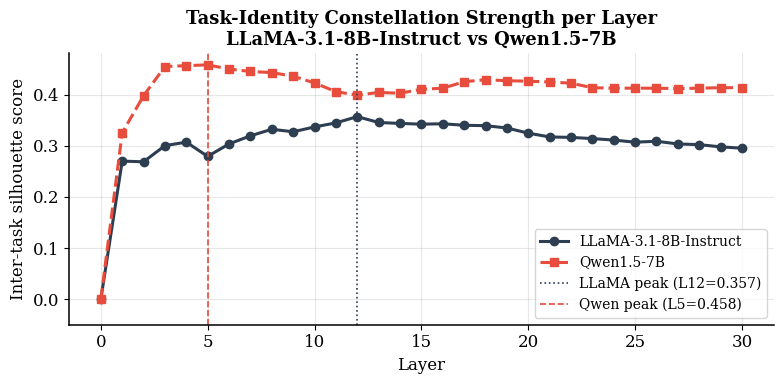

✓ Saved: fig_nb20_silhouette_comparison.png


In [10]:
# ── Figure 1: Silhouette layer profile — LLaMA vs Qwen ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(lnums_l, sil_l, 'o-', color=PAL['llama'], lw=2.2, label='LLaMA-3.1-8B-Instruct')
ax.plot(lnums_q, sil_q, 's--', color=PAL['qwen'],  lw=2.2, label='Qwen1.5-7B')

ax.axvline(LLAMA_PEAK_LAYER, color=PAL['llama'], lw=1.2, ls=':',
           label=f'LLaMA peak (L{LLAMA_PEAK_LAYER}={sil_l.max():.3f})')
ax.axvline(QWEN_PEAK_LAYER, color=PAL['qwen'], lw=1.2, ls='--',
           label=f'Qwen peak (L{QWEN_PEAK_LAYER}={sil_q.max():.3f})')

ax.set_xlabel('Layer')
ax.set_ylabel('Inter-task silhouette score')
ax.set_title('Task-Identity Constellation Strength per Layer\n'
             'LLaMA-3.1-8B-Instruct vs Qwen1.5-7B')
ax.legend(fontsize=10)
ax.set_ylim(bottom=-0.05)

plt.tight_layout()
plt.savefig('fig_nb20_silhouette_comparison.png', bbox_inches='tight', dpi=200)
plt.show()
print('✓ Saved: fig_nb20_silhouette_comparison.png')

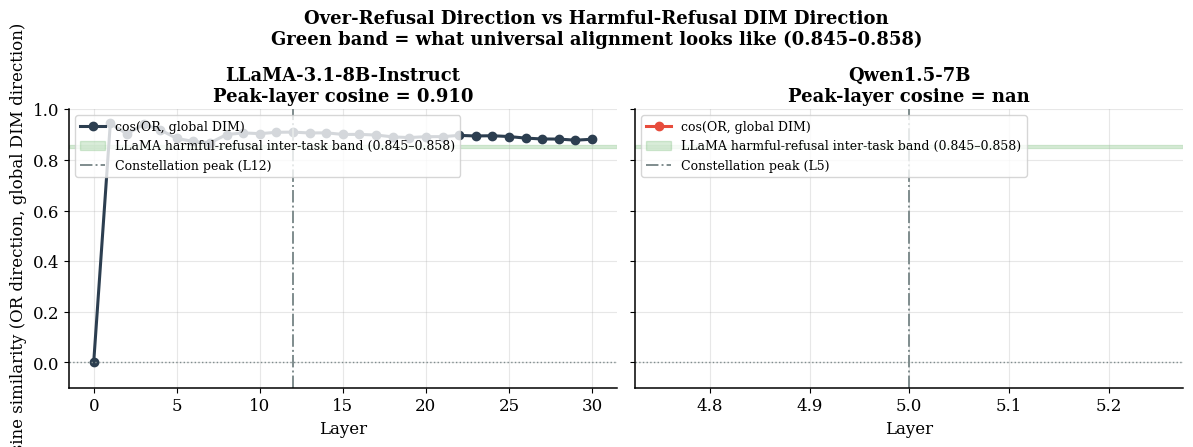

✓ Saved: fig_nb20_cosine_comparison.png


In [11]:
# ── Figure 2: OR vs global refusal direction cosine — LLaMA vs Qwen ──────────
# LLaMA reference band from NB9 (harmful-refusal inter-task alignment: 0.845–0.858)
LLAMA_HARM_BAND = (0.845, 0.858)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, model, lnums, cos, peak in [
    (axes[0], 'LLaMA-3.1-8B-Instruct', lnums_l_c, cos_l, LLAMA_PEAK_LAYER),
    (axes[1], 'Qwen1.5-7B',            lnums_q_c, cos_q, QWEN_PEAK_LAYER),
]:
    color = PAL['llama'] if 'LLaMA' in model else PAL['qwen']
    ax.plot(lnums, cos, 'o-', color=color, lw=2.2, label='cos(OR, global DIM)')
    ax.axhspan(*LLAMA_HARM_BAND, alpha=0.15, color='green',
               label='LLaMA harmful-refusal inter-task band (0.845–0.858)')
    ax.axvline(peak, color=PAL['ref'], lw=1.4, ls='-.',
               label=f'Constellation peak (L{peak})')
    ax.axhline(0, color=PAL['ref'], lw=1, ls=':')

    mid_cos = cos[lnums == peak]
    mid_val = mid_cos[0] if len(mid_cos) > 0 else np.nanmean(cos[10:20])
    ax.set_title(f'{model}\nPeak-layer cosine = {mid_val:.3f}', pad=6)
    ax.set_xlabel('Layer')
    ax.set_ylim(-0.1, 1.0)
    ax.legend(fontsize=9, loc='upper left')

axes[0].set_ylabel('Cosine similarity (OR direction, global DIM direction)')
plt.suptitle('Over-Refusal Direction vs Harmful-Refusal DIM Direction\n'
             'Green band = what universal alignment looks like (0.845–0.858)',
             fontsize=13, fontweight='bold')
plt.tight_layout(pad=0.8)
plt.savefig('fig_nb20_cosine_comparison.png', bbox_inches='tight', dpi=200)
plt.show()
print('✓ Saved: fig_nb20_cosine_comparison.png')

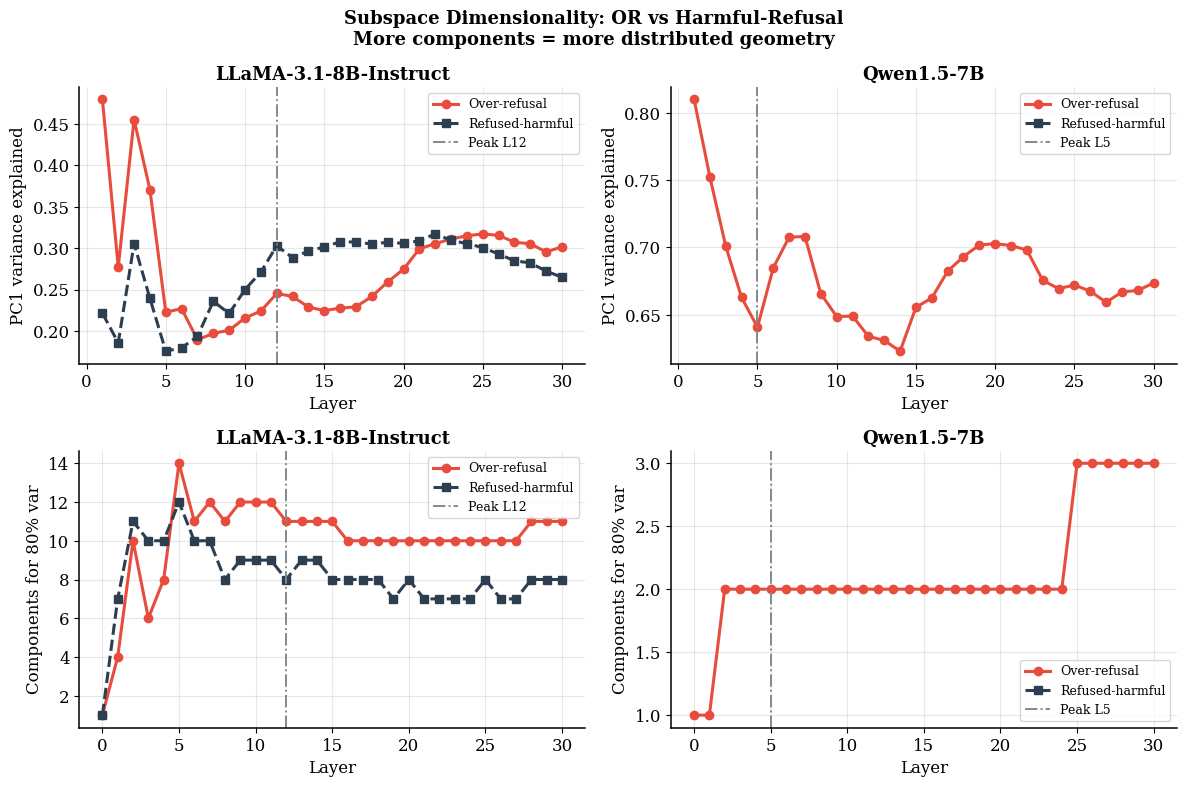

✓ Saved: fig_nb20_dimensionality_comparison.png


In [12]:
# ── Figure 3: Subspace dimensionality comparison ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_cfg = [
    ('or_pc1_var', 'PC1 variance explained', 'Top row: PC1 variance'),
    ('or_n80',     'Components for 80% var',  'Bottom row: n80'),
]

for row_i, (col, ylabel, _) in enumerate(plot_cfg):
    rh_col = col.replace('or_', 'rh_')
    for col_i, (model, dim, peak) in enumerate([
        ('LLaMA-3.1-8B-Instruct', dim_l, LLAMA_PEAK_LAYER),
        ('Qwen1.5-7B',            dim_q, QWEN_PEAK_LAYER),
    ]):
        ax  = axes[row_i][col_i]
        clr = PAL['llama'] if 'LLaMA' in model else PAL['qwen']

        ax.plot(dim['layer'], dim[col],    'o-',  color='#E74C3C', lw=2.2, label='Over-refusal')
        ax.plot(dim['layer'], dim[rh_col], 's--', color='#2C3E50', lw=2.2, label='Refused-harmful')
        ax.axvline(peak, color=PAL['ref'], lw=1.4, ls='-.', label=f'Peak L{peak}')

        ax.set_xlabel('Layer')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{model}', pad=5)
        ax.legend(fontsize=9)

plt.suptitle('Subspace Dimensionality: OR vs Harmful-Refusal\n'
             'More components = more distributed geometry',
             fontsize=13, fontweight='bold')
plt.tight_layout(pad=1.0)
plt.savefig('fig_nb20_dimensionality_comparison.png', bbox_inches='tight', dpi=200)
plt.show()
print('✓ Saved: fig_nb20_dimensionality_comparison.png')

## Summary Table

In [13]:
def row_at_peak(dim, peak):
    r = dim[dim['layer'] == peak]
    if r.empty:
        r = dim.iloc[[abs(dim['layer'] - peak).argmin()]]
    return r.iloc[0]

rl = row_at_peak(dim_l, LLAMA_PEAK_LAYER)
rq = row_at_peak(dim_q, QWEN_PEAK_LAYER)

cos_l_peak = cos_l[lnums_l_c == LLAMA_PEAK_LAYER]
cos_q_peak = cos_q[lnums_q_c == QWEN_PEAK_LAYER]

cl = float(cos_l_peak[0]) if len(cos_l_peak) else float(np.nanmean(cos_l))
cq = float(cos_q_peak[0]) if len(cos_q_peak) else float(np.nanmean(cos_q))

print('='*80)
print(f'{"Metric":<40} {"LLaMA-3.1-8B":>18} {"Qwen1.5-7B":>18}')
print('-'*80)
print(f'{"Constellation peak layer":<40} {f"L{LLAMA_PEAK_LAYER}":>18} {f"L{QWEN_PEAK_LAYER}":>18}')
print(f'{"Peak inter-task silhouette":<40} {sil_l.max():>18.3f} {sil_q.max():>18.3f}')
print(f'{"cos(OR, global DIM) at peak layer":<40} {cl:>18.3f} {cq:>18.3f}')
print(f'{"Harmful-refusal inter-task cos":<40} {"0.845–0.858":>18} {"(from NB9, LLaMA)":>18}')
print(f'{"OR PC1 variance at peak layer":<40} {rl.or_pc1_var:>17.1%} {rq.or_pc1_var:>17.1%}')
print(f'{"RH PC1 variance at peak layer":<40} {rl.rh_pc1_var:>17.1%} {rq.rh_pc1_var:>17.1%}')

or_l = int(rl.or_n80) if not np.isnan(rl.or_n80) else "nan"
or_q = int(rq.or_n80) if not np.isnan(rq.or_n80) else "nan"
rh_l = int(rl.rh_n80) if not np.isnan(rl.rh_n80) else "nan"
rh_q = int(rq.rh_n80) if not np.isnan(rq.rh_n80) else "nan"

print(f'{"OR n80 (components for 80% var)":<40} {or_l:>18} {or_q:>18}')
print(f'{"RH n80 (components for 80% var)":<40} {rh_l:>18} {rh_q:>18}')
print('='*80)

replicated = all([
    sil_q.max() > 0.1,                    # constellations exist
    not np.isnan(cq) and cq < 0.80,       # OR misaligned with DIM
    not np.isnan(rq.or_n80),
    not np.isnan(rq.rh_n80),
    rq.or_n80 >= rq.rh_n80,               # OR subspace ≥ RH dimensionality
])

print(f'\n{"✓ All 3 claims replicated on Qwen." if replicated else "⚠ Some claims NOT replicated — see rows above."}')

Metric                                         LLaMA-3.1-8B         Qwen1.5-7B
--------------------------------------------------------------------------------
Constellation peak layer                                L12                 L5
Peak inter-task silhouette                            0.357              0.458
cos(OR, global DIM) at peak layer                     0.910                nan
Harmful-refusal inter-task cos                  0.845–0.858  (from NB9, LLaMA)
OR PC1 variance at peak layer                        24.5%             64.1%
RH PC1 variance at peak layer                        30.3%              nan%
OR n80 (components for 80% var)                          11                  2
RH n80 (components for 80% var)                           8                nan

⚠ Some claims NOT replicated — see rows above.


In [14]:
import json

summary = {
    'qwen': {
        'peak_layer': int(QWEN_PEAK_LAYER),
        'peak_silhouette': float(sil_q.max()),
        'cos_or_dim_at_peak': float(cq),
        'or_pc1_var': float(rq.or_pc1_var),
        'rh_pc1_var': float(rq.rh_pc1_var),
        'or_n80': int(rq.or_n80) if not np.isnan(rq.or_n80) else None,
        'rh_n80': int(rq.rh_n80) if not np.isnan(rq.rh_n80) else None,
    },
    'llama': {
        'peak_layer': int(LLAMA_PEAK_LAYER),
        'peak_silhouette': float(sil_l.max()),
        'cos_or_dim_at_peak': float(cl),
        'or_pc1_var': float(rl.or_pc1_var),
        'rh_pc1_var': float(rl.rh_pc1_var),
        'or_n80': int(rl.or_n80) if not np.isnan(rl.or_n80) else None,
        'rh_n80': int(rl.rh_n80) if not np.isnan(rl.rh_n80) else None,
    },
}
with open('nb20_crossmodel_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

!cp nb20_crossmodel_summary.json \
   /content/drive/MyDrive/Colab\ Notebooks/SteeringFail/arditi_artefacts/
!cp fig_nb20_*.png /content/drive/MyDrive/Colab\ Notebooks/SteeringFail/

print('✓ All saved to Drive.')

✓ All saved to Drive.


In [15]:
from google.colab import runtime

# This will disconnect the runtime and stop the CU burn
runtime.unassign()